# Analyze HATR Result Folders

This Colab notebook compares HATR experiments under `/content/drive/MyDrive/DCASE2026`.

It is designed for folders such as:

- `hatr_bsd10k_colab`
- `hatr_bsd10k_colab_no_conf1`
- `hatr_bsd10k_colab_select_class_confi1`

It compares fold-level metrics, mean ± std metrics, class distributions, and per-class prediction behavior when prediction CSVs are available.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

ROOT = Path('/content/drive/MyDrive/DCASE2026')
REPORT_DIR = ROOT / 'hatr_result_analysis_report'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

CANDIDATE_EXPERIMENTS = {
    'all_confidence': ROOT / 'hatr_bsd10k_colab',
    'no_confidence1': ROOT / 'hatr_bsd10k_colab_no_conf1',
    'select_confidence1_classes': ROOT / 'hatr_bsd10k_colab_select_class_confi1',
}

EXPERIMENTS = {name: path for name, path in CANDIDATE_EXPERIMENTS.items() if path.exists()}
print('Found experiments:')
for name, path in EXPERIMENTS.items():
    print(f'  {name}: {path}')

if not EXPERIMENTS:
    raise FileNotFoundError('No expected HATR result folders found under /content/drive/MyDrive/DCASE2026')

Mounted at /content/drive
Found experiments:
  all_confidence: /content/drive/MyDrive/DCASE2026/hatr_bsd10k_colab
  no_confidence1: /content/drive/MyDrive/DCASE2026/hatr_bsd10k_colab_no_conf1


In [2]:
# Locate useful files in each experiment
def find_first(root, names):
    for name in names:
        hits = list(root.rglob(name))
        if hits:
            return hits[0]
    return None

def experiment_layout(path):
    return {
        'fold_summary': find_first(path, ['fold_summary.csv', 'summary_audio_test.csv', 'summary.csv']),
        'mean_std': find_first(path, ['baseline_style_metrics_mean_std.csv', 'summary_audio_test_mean_std.csv']),
        'processed_dataset': find_first(path, ['processed_dataset.csv']),
        'class_dict': find_first(path, ['class_dict.json']),
        'top_class_dict': find_first(path, ['top_class_dict.json']),
        'predictions': sorted(path.rglob('predictions*.csv')),
        'confusion_npy': sorted(path.rglob('confusion_matrix*.npy')),
    }

layouts = {name: experiment_layout(path) for name, path in EXPERIMENTS.items()}
for name, layout in layouts.items():
    print('\n==', name, '==')
    for key, value in layout.items():
        if isinstance(value, list):
            print(key, len(value))
            for item in value[:5]:
                print(' ', item)
        else:
            print(key, value)


== all_confidence ==
fold_summary /content/drive/MyDrive/DCASE2026/hatr_bsd10k_colab/model_output/fold_summary.csv
mean_std /content/drive/MyDrive/DCASE2026/hatr_bsd10k_colab/model_output/baseline_style_metrics_mean_std.csv
processed_dataset /content/drive/MyDrive/DCASE2026/hatr_bsd10k_colab/data/processed_dataset.csv
class_dict /content/drive/MyDrive/DCASE2026/hatr_bsd10k_colab/data/class_dict.json
top_class_dict /content/drive/MyDrive/DCASE2026/hatr_bsd10k_colab/data/top_class_dict.json
predictions 5
  /content/drive/MyDrive/DCASE2026/hatr_bsd10k_colab/model_output/fold_1/predictions.csv
  /content/drive/MyDrive/DCASE2026/hatr_bsd10k_colab/model_output/fold_2/predictions.csv
  /content/drive/MyDrive/DCASE2026/hatr_bsd10k_colab/model_output/fold_3/predictions.csv
  /content/drive/MyDrive/DCASE2026/hatr_bsd10k_colab/model_output/fold_4/predictions.csv
  /content/drive/MyDrive/DCASE2026/hatr_bsd10k_colab/model_output/fold_5/predictions.csv
confusion_npy 5
  /content/drive/MyDrive/DCASE

In [3]:
# Fold metric comparison
METRIC_COLS = [
    'accuracy',
    'top_accuracy',
    'macro_accuracy',
    'macro_top_accuracy',
    'hierarchical_accuracy',
    'hierarchical_precision',
    'hierarchical_recall',
    'hierarchical_f1',
]

summary_frames = []
for exp_name, layout in layouts.items():
    path = layout['fold_summary']
    if path is None:
        print('missing fold summary:', exp_name)
        continue
    df = pd.read_csv(path)
    df['experiment'] = exp_name
    df['source_file'] = str(path)
    summary_frames.append(df)

all_folds = pd.concat(summary_frames, ignore_index=True) if summary_frames else pd.DataFrame()
all_folds.to_csv(REPORT_DIR / 'all_fold_metrics.csv', index=False)
display(all_folds)

available_metrics = [m for m in METRIC_COLS if m in all_folds.columns]
metric_summary = []
for exp_name, group in all_folds.groupby('experiment', sort=False):
    row = {'experiment': exp_name, 'fold_count': len(group)}
    for metric in available_metrics:
        values = pd.to_numeric(group[metric], errors='coerce').dropna()
        row[f'{metric}_mean'] = values.mean() if len(values) else np.nan
        row[f'{metric}_std'] = values.std(ddof=0) if len(values) else np.nan
        row[f'{metric}_mean_pm_std'] = f"{row[f'{metric}_mean']:.2f} ± {row[f'{metric}_std']:.2f}" if len(values) else ''
    metric_summary.append(row)

metric_summary = pd.DataFrame(metric_summary)
metric_summary.to_csv(REPORT_DIR / 'experiment_metric_mean_std.csv', index=False)
display(metric_summary)

,fold,best_val_acc,test_acc,experiment,source_file,accuracy,top_accuracy,macro_accuracy,macro_top_accuracy,hierarchical_accuracy,hierarchical_precision,hierarchical_recall,hierarchical_f1
0,1,0.798631,0.791058,all_confidence,/content/drive/MyDrive/DCASE2026/hatr_bsd10k_c...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,0.795208,0.798722,all_confidence,/content/drive/MyDrive/DCASE2026/hatr_bsd10k_c...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,0.819738,0.790963,all_confidence,/content/drive/MyDrive/DCASE2026/hatr_bsd10k_c...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,0.800913,0.804199,all_confidence,/content/drive/MyDrive/DCASE2026/hatr_bsd10k_c...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,0.814604,0.806025,all_confidence,/content/drive/MyDrive/DCASE2026/hatr_bsd10k_c...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1,0.808511,0.806808,no_confidence1,/content/drive/MyDrive/DCASE2026/hatr_bsd10k_c...,80.680773,90.248390,74.474979,85.102138,79.788559,78.783656,77.101468,77.485612
6,2,0.811961,0.810028,no_confidence1,/content/drive/MyDrive/DCASE2026/hatr_bsd10k_c...,81.002760,89.788408,75.193050,85.312833,80.252941,79.217394,77.850845,78.281127
7,3,0.805060,0.790152,no_confidence1,/content/drive/MyDrive/DCASE2026/hatr_bsd10k_c...,79.015186,89.415555,73.335400,86.819940,80.077670,76.600688,77.020865,76.661359
8,4,0.813111,0.825587,no_confidence1,/content/drive/MyDrive/DCASE2026/hatr_bsd10k_c...,82.558675,90.473999,76.498780,85.893161,81.195970,80.191647,78.866782,79.295067
9,5,0.809086,0.786931,no_confidence1,/content/drive/MyDrive/DCASE2026/hatr_bsd10k_c...,78.693051,88.127013,74.593692,84.556836,79.575264,76.582985,77.005143,76.439081


,experiment,fold_count,accuracy_mean,accuracy_std,accuracy_mean_pm_std,top_accuracy_mean,top_accuracy_std,top_accuracy_mean_pm_std,macro_accuracy_mean,macro_accuracy_std,...,hierarchical_accuracy_mean_pm_std,hierarchical_precision_mean,hierarchical_precision_std,hierarchical_precision_mean_pm_std,hierarchical_recall_mean,hierarchical_recall_std,hierarchical_recall_mean_pm_std,hierarchical_f1_mean,hierarchical_f1_std,hierarchical_f1_mean_pm_std
0,all_confidence,5,NaN,NaN,,NaN,NaN,,NaN,NaN,...,,NaN,NaN,,NaN,NaN,,NaN,NaN,
1,no_confidence1,5,80.390089,1.409462,80.39 ± 1.41,89.610673,0.827396,89.61 ± 0.83,74.81918,1.032643,...,80.18 ± 0.56,78.275274,1.448213,78.28 ± 1.45,77.56902,0.7212,77.57 ± 0.72,77.632449,1.055821,77.63 ± 1.06


In [4]:
# Paired fold differences versus all_confidence
if 'all_confidence' in all_folds['experiment'].unique():
    baseline = all_folds[all_folds['experiment'] == 'all_confidence'].copy()
    diff_rows = []
    for exp_name in all_folds['experiment'].unique():
        if exp_name == 'all_confidence':
            continue
        comp = all_folds[all_folds['experiment'] == exp_name].copy()
        if 'fold' not in baseline.columns or 'fold' not in comp.columns:
            continue
        merged = baseline.merge(comp, on='fold', suffixes=('_all', f'_{exp_name}'))
        for metric in available_metrics:
            a = pd.to_numeric(merged[f'{metric}_all'], errors='coerce')
            b = pd.to_numeric(merged[f'{metric}_{exp_name}'], errors='coerce')
            delta = b - a
            diff_rows.append({
                'comparison': f'{exp_name} - all_confidence',
                'metric': metric,
                'mean_delta': delta.mean(),
                'std_delta': delta.std(ddof=0),
                'improved_folds': int((delta > 0).sum()),
                'worse_folds': int((delta < 0).sum()),
                'same_folds': int((delta == 0).sum()),
                'fold_deltas': ', '.join([f'{x:.2f}' for x in delta.tolist()]),
            })
    diff_df = pd.DataFrame(diff_rows)
    diff_df.to_csv(REPORT_DIR / 'paired_fold_differences_vs_all_confidence.csv', index=False)
    display(diff_df)
else:
    print('No all_confidence experiment found, skipping paired differences.')

,comparison,metric,mean_delta,std_delta,improved_folds,worse_folds,same_folds,fold_deltas
0,no_confidence1 - all_confidence,accuracy,NaN,NaN,0,0,0,"nan, nan, nan, nan, nan"
1,no_confidence1 - all_confidence,top_accuracy,NaN,NaN,0,0,0,"nan, nan, nan, nan, nan"
2,no_confidence1 - all_confidence,macro_accuracy,NaN,NaN,0,0,0,"nan, nan, nan, nan, nan"
3,no_confidence1 - all_confidence,macro_top_accuracy,NaN,NaN,0,0,0,"nan, nan, nan, nan, nan"
4,no_confidence1 - all_confidence,hierarchical_accuracy,NaN,NaN,0,0,0,"nan, nan, nan, nan, nan"
5,no_confidence1 - all_confidence,hierarchical_precision,NaN,NaN,0,0,0,"nan, nan, nan, nan, nan"
6,no_confidence1 - all_confidence,hierarchical_recall,NaN,NaN,0,0,0,"nan, nan, nan, nan, nan"
7,no_confidence1 - all_confidence,hierarchical_f1,NaN,NaN,0,0,0,"nan, nan, nan, nan, nan"


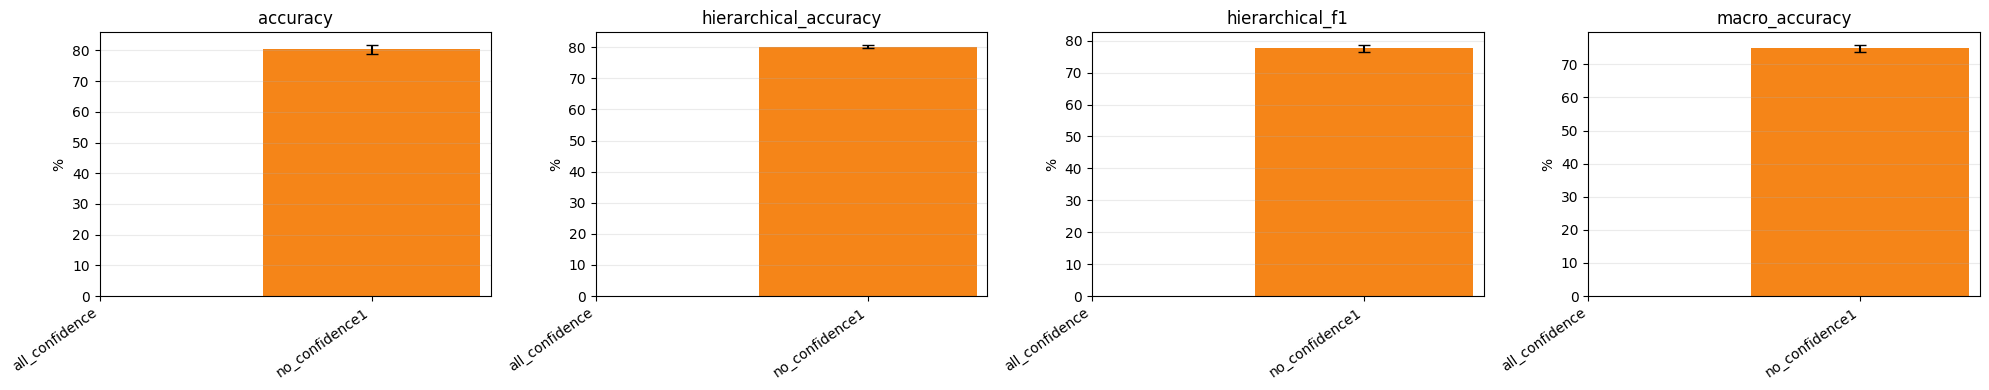

saved: /content/drive/MyDrive/DCASE2026/hatr_result_analysis_report/main_metric_comparison.png


In [5]:
# Plot main metrics
plot_metrics = [m for m in ['accuracy', 'hierarchical_accuracy', 'hierarchical_f1', 'macro_accuracy'] if f'{m}_mean' in metric_summary.columns]
if plot_metrics:
    fig, axes = plt.subplots(1, len(plot_metrics), figsize=(5 * len(plot_metrics), 4), squeeze=False)
    for ax, metric in zip(axes[0], plot_metrics):
        x = np.arange(len(metric_summary))
        means = metric_summary[f'{metric}_mean'].to_numpy(dtype=float)
        stds = metric_summary[f'{metric}_std'].to_numpy(dtype=float)
        ax.bar(x, means, yerr=stds, capsize=4, color=['#4C78A8', '#F58518', '#54A24B', '#B279A2'][:len(x)])
        ax.set_xticks(x)
        ax.set_xticklabels(metric_summary['experiment'], rotation=35, ha='right')
        ax.set_title(metric)
        ax.set_ylabel('%')
        ax.grid(axis='y', alpha=0.25)
    fig.tight_layout()
    plot_path = REPORT_DIR / 'main_metric_comparison.png'
    fig.savefig(plot_path, dpi=180, bbox_inches='tight')
    plt.show()
    print('saved:', plot_path)

In [6]:
# Dataset composition comparison, if processed_dataset.csv exists
composition_rows = []
class_count_frames = []
for exp_name, layout in layouts.items():
    path = layout['processed_dataset']
    if path is None:
        print('missing processed_dataset:', exp_name)
        continue
    df = pd.read_csv(path)
    composition_rows.append({
        'experiment': exp_name,
        'samples': len(df),
        'classes': df['class'].nunique() if 'class' in df.columns else np.nan,
        'top_classes': df['top_class'].nunique() if 'top_class' in df.columns else np.nan,
    })
    if 'class' in df.columns:
        counts = df['class'].value_counts().rename(exp_name)
        class_count_frames.append(counts)

composition = pd.DataFrame(composition_rows)
composition.to_csv(REPORT_DIR / 'dataset_composition.csv', index=False)
display(composition)

if class_count_frames:
    class_counts = pd.concat(class_count_frames, axis=1).fillna(0).astype(int)
    class_counts['max_minus_min'] = class_counts.max(axis=1) - class_counts.min(axis=1)
    class_counts = class_counts.sort_values('max_minus_min', ascending=False)
    class_counts.to_csv(REPORT_DIR / 'class_count_changes.csv')
    display(class_counts.head(30))

,experiment,samples,classes,top_classes
0,all_confidence,10956,23,5
1,no_confidence1,10956,23,5


,all_confidence,no_confidence1,max_minus_min
class,,,
fx-o,1211,1211,0
fx-h,975,975,0
sp-s,806,806,0
m-si,721,721,0
ss-u,719,719,0
m-sp,683,683,0
fx-n,652,652,0
is-p,606,606,0
is-w,566,566,0


In [7]:
# Per-class metrics from fold prediction CSVs, if available
def read_prediction_file(path):
    df = pd.read_csv(path)
    if {'y_true', 'y_pred'}.issubset(df.columns):
        return df[['y_true', 'y_pred']].rename(columns={'y_true': 'true_id', 'y_pred': 'pred_id'})
    if {'ground_truth', 'prediction'}.issubset(df.columns):
        return df[['ground_truth', 'prediction']].rename(columns={'ground_truth': 'true_label', 'prediction': 'pred_label'})
    return None

def load_id_to_class(layout):
    if layout['class_dict'] is None:
        return None
    with open(layout['class_dict']) as f:
        class_dict = json.load(f)
    return {int(v): k for k, v in class_dict.items()}

per_class_frames = []
for exp_name, layout in layouts.items():
    id_to_class = load_id_to_class(layout)
    pred_files = [p for p in layout['predictions'] if 'prediction' in p.name.lower()]
    if not pred_files:
        print('missing predictions:', exp_name)
        continue
    rows = []
    for path in pred_files:
        pred = read_prediction_file(path)
        if pred is None:
            continue
        if {'true_id', 'pred_id'}.issubset(pred.columns):
            pred['true_label'] = pred['true_id'].astype(int).map(id_to_class) if id_to_class else pred['true_id'].astype(str)
            pred['pred_label'] = pred['pred_id'].astype(int).map(id_to_class) if id_to_class else pred['pred_id'].astype(str)
        labels = sorted(pred['true_label'].dropna().unique())
        precision, recall, f1, support = precision_recall_fscore_support(
            pred['true_label'], pred['pred_label'], labels=labels, zero_division=0
        )
        fold_name = path.parent.name
        for label, p, r, f, s in zip(labels, precision, recall, f1, support):
            rows.append({'experiment': exp_name, 'fold': fold_name, 'class': label, 'precision': p, 'recall': r, 'f1': f, 'support': s})
    if rows:
        per_class_frames.append(pd.DataFrame(rows))

per_class = pd.concat(per_class_frames, ignore_index=True) if per_class_frames else pd.DataFrame()
per_class.to_csv(REPORT_DIR / 'per_class_fold_metrics.csv', index=False)
display(per_class.head())

if not per_class.empty:
    per_class_summary = per_class.groupby(['experiment', 'class']).agg(
        precision_mean=('precision', 'mean'),
        recall_mean=('recall', 'mean'),
        f1_mean=('f1', 'mean'),
        support_mean=('support', 'mean'),
    ).reset_index()
    per_class_summary.to_csv(REPORT_DIR / 'per_class_metric_summary.csv', index=False)
    display(per_class_summary.head())

,experiment,fold,class,precision,recall,f1,support
0,all_confidence,fold_1,fx-a,0.800000,0.470588,0.592593,34
1,all_confidence,fold_1,fx-el,0.697674,0.714286,0.705882,42
2,all_confidence,fold_1,fx-ex,0.500000,0.355932,0.415842,59
3,all_confidence,fold_1,fx-h,0.866667,0.866667,0.866667,195
4,all_confidence,fold_1,fx-m,0.709677,0.800000,0.752137,55


,experiment,class,precision_mean,recall_mean,f1_mean,support_mean
0,all_confidence,fx-a,0.659620,0.572906,0.601844,33.2
1,all_confidence,fx-el,0.700844,0.667828,0.680171,41.6
2,all_confidence,fx-ex,0.602189,0.481356,0.530644,59.4
3,all_confidence,fx-h,0.863346,0.893333,0.877365,195.0
4,all_confidence,fx-m,0.703301,0.799286,0.746417,55.8


In [8]:
# Per-class deltas versus all_confidence
if not per_class.empty and 'all_confidence' in per_class['experiment'].unique():
    pcs = per_class.groupby(['experiment', 'class']).agg(
        recall=('recall', 'mean'),
        f1=('f1', 'mean'),
        support=('support', 'mean'),
    ).reset_index()
    base = pcs[pcs['experiment'] == 'all_confidence'].drop(columns='experiment')
    delta_frames = []
    for exp_name in pcs['experiment'].unique():
        if exp_name == 'all_confidence':
            continue
        comp = pcs[pcs['experiment'] == exp_name].drop(columns='experiment')
        merged = base.merge(comp, on='class', suffixes=('_all', f'_{exp_name}'))
        merged['experiment'] = exp_name
        merged['delta_recall'] = merged[f'recall_{exp_name}'] - merged['recall_all']
        merged['delta_f1'] = merged[f'f1_{exp_name}'] - merged['f1_all']
        delta_frames.append(merged)
    class_deltas = pd.concat(delta_frames, ignore_index=True) if delta_frames else pd.DataFrame()
    class_deltas.to_csv(REPORT_DIR / 'per_class_deltas_vs_all_confidence.csv', index=False)
    display(class_deltas.sort_values('delta_f1').head(20))
    display(class_deltas.sort_values('delta_f1', ascending=False).head(20))
else:
    print('Per-class delta skipped. Need predictions and all_confidence experiment.')

,class,recall_all,f1_all,support_all,recall_no_confidence1,f1_no_confidence1,support_no_confidence1,experiment,delta_recall,delta_f1
0,fx-a,0.572906,0.601844,33.2,0.506061,0.552778,33.2,no_confidence1,-0.066845,-0.049066
21,ss-s,0.820085,0.811121,43.4,0.786047,0.787927,43.0,no_confidence1,-0.034038,-0.023194
4,fx-m,0.799286,0.746417,55.8,0.785325,0.726079,55.8,no_confidence1,-0.013961,-0.020338
22,ss-u,0.649485,0.663075,143.8,0.631530,0.652128,140.6,no_confidence1,-0.017955,-0.010948
5,fx-n,0.912566,0.854234,130.4,0.886154,0.843992,130.0,no_confidence1,-0.026412,-0.010242
20,ss-n,0.685232,0.696622,78.2,0.680486,0.688378,77.6,no_confidence1,-0.004746,-0.008244
6,fx-o,0.856294,0.868488,242.2,0.853942,0.862389,241.0,no_confidence1,-0.002352,-0.006099
7,fx-v,0.641585,0.622614,40.2,0.622317,0.619112,40.2,no_confidence1,-0.019268,-0.003501
12,is-w,0.964633,0.962235,113.2,0.966277,0.958833,112.6,no_confidence1,0.001644,-0.003402
9,is-k,0.925228,0.927183,72.4,0.950381,0.924154,72.4,no_confidence1,0.025152,-0.003030


,class,recall_all,f1_all,support_all,recall_no_confidence1,f1_no_confidence1,support_no_confidence1,experiment,delta_recall,delta_f1
19,ss-i,0.381417,0.448660,41.4,0.507927,0.498529,40.6,no_confidence1,0.126510,0.049869
13,m-m,0.581827,0.598754,64.6,0.583894,0.642573,64.4,no_confidence1,0.002067,0.043819
14,m-si,0.780833,0.766166,144.2,0.828563,0.795989,142.4,no_confidence1,0.047730,0.029823
15,m-sp,0.855109,0.835440,136.6,0.870251,0.859549,135.6,no_confidence1,0.015141,0.024109
8,is-e,0.677119,0.697596,59.4,0.701695,0.718362,59.0,no_confidence1,0.024576,0.020767
16,sp-c,0.513810,0.491035,35.4,0.475397,0.510348,35.4,no_confidence1,-0.038413,0.019313
10,is-p,0.851484,0.867084,121.2,0.875634,0.883794,120.6,no_confidence1,0.024150,0.016710
1,fx-el,0.667828,0.680171,41.6,0.679559,0.692189,41.2,no_confidence1,0.011731,0.012018
3,fx-h,0.893333,0.877365,195.0,0.910827,0.885842,192.8,no_confidence1,0.017494,0.008477
2,fx-ex,0.481356,0.530644,59.4,0.508650,0.538084,58.2,no_confidence1,0.027294,0.007440


In [9]:
# Text conclusion helper
print('Report saved to:', REPORT_DIR)
print('\nKey files:')
for name in [
    'experiment_metric_mean_std.csv',
    'paired_fold_differences_vs_all_confidence.csv',
    'dataset_composition.csv',
    'class_count_changes.csv',
    'per_class_deltas_vs_all_confidence.csv',
    'main_metric_comparison.png',
]:
    path = REPORT_DIR / name
    print(path, 'exists=' + str(path.exists()))

if 'metric_summary' in globals() and not metric_summary.empty:
    print('\nMetric summary:')
    for _, row in metric_summary.iterrows():
        print('\n', row['experiment'])
        for metric in ['accuracy', 'hierarchical_accuracy', 'hierarchical_f1']:
            col = f'{metric}_mean_pm_std'
            if col in row:
                print(f'  {metric}: {row[col]}')

Report saved to: /content/drive/MyDrive/DCASE2026/hatr_result_analysis_report

Key files:
/content/drive/MyDrive/DCASE2026/hatr_result_analysis_report/experiment_metric_mean_std.csv exists=True
/content/drive/MyDrive/DCASE2026/hatr_result_analysis_report/paired_fold_differences_vs_all_confidence.csv exists=True
/content/drive/MyDrive/DCASE2026/hatr_result_analysis_report/dataset_composition.csv exists=True
/content/drive/MyDrive/DCASE2026/hatr_result_analysis_report/class_count_changes.csv exists=True
/content/drive/MyDrive/DCASE2026/hatr_result_analysis_report/per_class_deltas_vs_all_confidence.csv exists=True
/content/drive/MyDrive/DCASE2026/hatr_result_analysis_report/main_metric_comparison.png exists=True

Metric summary:

 all_confidence
  accuracy: 
  hierarchical_accuracy: 
  hierarchical_f1: 

 no_confidence1
  accuracy: 80.39 ± 1.41
  hierarchical_accuracy: 80.18 ± 0.56
  hierarchical_f1: 77.63 ± 1.06
